# IIA - Trabajo Práctico 3 - Redes Neuronales
# Santiago Bussanich - Lucas Wasserstromm - Agustín López

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import mean_squared_error, zero_one_loss

from typing import Tuple

import time
from copy import deepcopy

# Explorando las Redes

In [3]:
# Parámetros
"""
Comenzar y frenar el entrenamiento de una red es costoso, por lo que no
mediremos las métricas una vez por época, sino que haremos varias épocas a la
vez. Por ésto definimos sub-épocas, por ejemplo como 10, para realizar 10 épocas
a la vez y luego medir las métricas de error.
"""
sub_epocas = 25   # numero de epocas que entrena cada vez
super_epocas = 100 # numero de veces que realizaremos sub-epocas
# epocas ~= sub_epocas * super_epocas
eta = 0.01        # learning rate
alfa = 0.9        # momentum
N2 = 60            # neuronas en la capa oculta

## Definimos nuestras redes


In [20]:
# Defino MLP para regresión
regr = MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(regr)

MLPRegressor(activation='logistic', alpha=0.0, batch_size=1,
             hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
             nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


In [21]:
# Defino MLP para clasificación
clasif = MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(clasif)

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


## Entrenamos

> **Warning**: el entrenamiento de las redes es computacionalmente pesado. Algunos de los entrenamientos que se plantean en el trabajo llevan varios minutos, dependiendo de la velocidad del procesador. El tiempo máximo en Google Colab fue de alrededor de 10 minutos. Tengan eso en cuenta para hacer el trabajo.



In [22]:
def cargar_csv(path, xcols=2, sep=","):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
      sep (str): separador de columnas usado en el archivo
    """
    df = pd.read_csv(path, sep=sep, header=None)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

In [23]:
def entrenar_red(red, evaluaciones,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      best_red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
        # ACTUALIZACION PARA EJERCICIO 2: Necesitamos devolver el mejor error de test,
        # el cual es el de la mejor red (es decir, la red antes de que empiece a hacer overfitting)
        best_err_test = error_test[-1] # devolvemos el último
    return best_red, error_train, error_val, error_test, best_err_test

def entrenar_red_reg(red, evaluaciones,
                     X_train, y_train,
                     X_val,   y_val,
                     X_test,  y_test):
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    for epoch in range(evaluaciones):
      red.fit(X_train, y_train)
      y_pred_train = red.predict(X_train)
      error_train.append(mean_squared_error(y_train, y_pred_train))
      y_pred_val = red.predict(X_val)
      cur_val = mean_squared_error(y_val, y_pred_val)
      error_val.append(cur_val)
      y_pred_test = red.predict(X_test)
      error_test.append(mean_squared_error(y_test, y_pred_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test

In [27]:
# Cargamos los datos...
X, y = cargar_csv('xor.csv')

# Hacemos el split de training y testing
X2, X_test, y2, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.2)  # para xor de 200 me quedan 40 de test

# y spliteamos el training en training y validacion
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X2, y2, test_size=0.2)  # para xor de 160 me quedan 32 de val

# Corremos el entrenamiento
clasif, e_train, e_val, e_test, _ = entrenar_red(
    clasif, super_epocas, X_train, y_train, X_val, y_val, X_test, y_test)

## Ploteamos Algunas Métricas

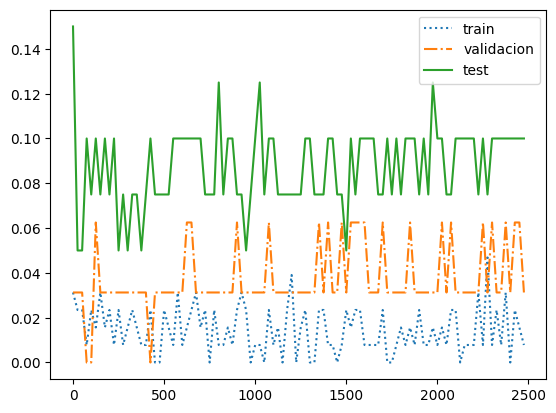

In [31]:
rango = np.array(range(super_epocas)) * sub_epocas
plt.plot(rango, e_train, label="train", linestyle=":")
plt.plot(rango, e_val, label="validacion", linestyle="-.")
plt.plot(rango, e_test, label="test", linestyle="-")
plt.legend()
plt.show()

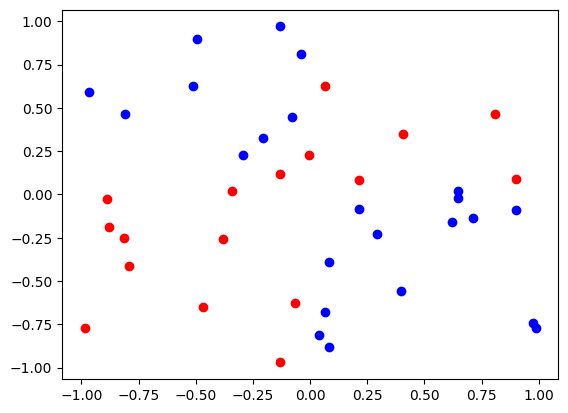

In [32]:
y_out = clasif.predict(X_test)
X_out = X_test.copy()
X_out[2] = y_out

# diferenciar entre clase 0 y clase 1
c0 = X_out.loc[X_out[2] == 0]
c1 = X_out.loc[X_out[2] == 1]

xs0 = c0[0].values.tolist()
ys0 = c0[1].values.tolist()

xs1 = c1[0].values.tolist()
ys1 = c1[1].values.tolist()

plt.scatter(xs0, ys0, color='red')
plt.scatter(xs1, ys1, color='blue')
plt.show()

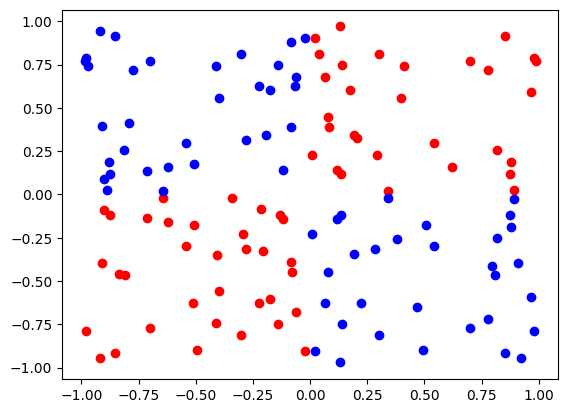

In [33]:
# diferenciar entre clase 0 y clase 1
Xt = X_train.copy()
Xt[2] = y_train
c0 = Xt.loc[Xt[2] == 0]
c1 = Xt.loc[Xt[2] == 1]

xs0 = c0[0].values.tolist()
ys0 = c0[1].values.tolist()

xs1 = c1[0].values.tolist()
ys1 = c1[1].values.tolist()

plt.scatter(xs0, ys0, color='red')
plt.scatter(xs1, ys1, color='blue')
plt.show()

# Ejercicio 1. Capacidad de Modelado.

Investigando como funciona la librería sklearn, entendimos varias cosas:
*   El parámetro de la función que crea la red "activation", el cual claramente está pensado sobre qué función de activación usar en cada neurona, es la función de activación únicamente de las neuronas de la(s) capa(s) oculta(s). La función de activación que se usa en la última capa (la capa de output o salida) depende del tipo de red que estemos entrenando (clasificación o regresión).
*   Para el caso de clasificación binario, es decir que el problema solo admite como clases 0 y 1, la capa de salida consiste en una única neurona que usa como función de activación nuevamente la función logística o sigmoide. Si la red se usa para problemas de clasificación multiclase, entonces la capa de salida consta de K neuronas (una por clase) y la función de activación  **softmax** vista en clase en cada neurona. Esto es de esta manera porque la función sigmoide devuelve un valor entre 0 y 1, y entonces la suma de los valores de salida de cada neurona podría no estar normalizado, es decir, que su suma no sea 1.
*   Si bien ambas redes usan Stochastic Gradient Descent (sgd) para minimizar el error, las funciones de error que se usan dependen claramente del tipo de problema. Para los problemas de regresión, la función de error es la que se muestra en el libro (Mitchell, cap 4). Cuando el problema es de clasificación, se utiliza una función de error llamada "Entropía Cruzada". Las funciones MSE y Zero-One Loss se usan como métrica de la accuracy dependiendo del problema, pero no hay que confundirlas con las que se usan para descenso del gradiente.

In [34]:
def diagonales(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera sampleos de dos gausianas d-dimensionales en posición diagonal
    (una respecto a la otra), con dispersión C * sqrt(d).
    Cada sampleo posee n/2 puntos.

    Argumentos:
        d: número de dimensiones
        C: constante de ajuste de dispersión
        n: número de ejemplos a generar

    Retorna:
        X: matriz con d columnas y n filas de datos
        y: arreglo de n elementos con las clases correspondientes
            a cada fila de datos
    """
    std = C * np.sqrt(d)
    cov = np.diag(np.full(d, std**2))

    X, y = np.array([]), np.array([])

    mean_1 = np.ones(d)
    mean_0 = -np.ones(d)

    half = n // 2

    X_1 = np.random.multivariate_normal(mean_1, cov, half)
    X_0 = np.random.multivariate_normal(mean_0, cov, half)

    X = np.vstack([X_0, X_1])
    y = np.hstack([np.zeros(half), np.ones(half)])

    return X, y

def paralelas(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:

  X, y = np.array([]), np.array([])

  mean_1 = np.full(d,0)
  mean_1[0] = 1

  mean_0 = np.full(d,0)
  mean_0[0] = -1

  half = n // 2

  X_1 = np.random.multivariate_normal(mean_1, (C**2)*np.eye(d), half)
  X_0 = np.random.multivariate_normal(mean_0, (C**2)*np.eye(d), half)

  X = np.vstack([X_0, X_1])
  y = np.hstack([np.zeros(half), np.ones(half)])

  return X, y

def espirales(n: int) -> Tuple[np.ndarray, np.ndarray]:
    half = n // 2
    X0, X1 = [], []

    while len(X0) < half or len(X1) < half:
        x = np.random.uniform(-1, 1)
        yc = np.random.uniform(-1, 1)

        r = np.sqrt(x**2 + yc**2)
        if r > 1 or r == 0:
            continue

        # theta base en [0, 2*pi)
        theta = np.arctan2(yc, x) % (2 * np.pi)

        # Probamos theta y theta + 2*pi (segunda vuelta)
        # En cuál de las dos vueltas cae el punto según su r
        in_band = False
        for k in range(-1,3):  # hasta 3 vueltas
            t = theta + 2 * np.pi * k
            rho_low  = t / (4 * np.pi)
            rho_high = (t + np.pi) / (4 * np.pi)
            if rho_low <= r <= rho_high:
                in_band = True
                break

        label = 0 if in_band else 1

        if label == 0 and len(X0) < half:
            X0.append([x, yc])
        elif label == 1 and len(X1) < half:
            X1.append([x, yc])

    X = np.array(X0 + X1)
    y = np.hstack([np.zeros(half), np.ones(half)])
    return X, y

Generamos el conjunto de test y de entrenamiento


In [35]:
#Generamos el conjunto de datos, de los cuales usaremos 600 para ajustar la red, y 2000 para test.
XTot, YTot = espirales(2600)

# Dividimos, primero para los 600 de train y luego para los de validación
X_trainOrig, X_test, y_trainOrig, y_test = skl.model_selection.train_test_split(
    XTot, YTot, test_size=2000) # si test size es int, toma esa cantidad

X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X_trainOrig, y_trainOrig, test_size=0.2) # si test size es float, entonces debe ser entre 0 y 1, y toma ese porcentaje

Ahora definimos algunas redes

In [36]:
red1 = MLPClassifier(
    hidden_layer_sizes=(2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.1,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=20
)

red2 = MLPClassifier(
    hidden_layer_sizes=(10,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.1,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=20
)

red3 = MLPClassifier(
    hidden_layer_sizes=(20,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.1,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=20
)

red4 = MLPClassifier(
    hidden_layer_sizes=(40,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.1,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=20
)

cl1, e1_train, e1_val, e1_test, e1_bestErr = entrenar_red(red1, 1000, X_train, y_train, X_val, y_val, X_test, y_test)

cl2, e2_train, e2_val, e2_test, e2_bestErr = entrenar_red(red2, 1000, X_train, y_train, X_val, y_val, X_test, y_test)

cl3, e3_train, e3_val, e3_test, e3_bestErr = entrenar_red(red3, 1000, X_train, y_train, X_val, y_val, X_test, y_test)

cl4, e4_train, e4_val, e4_test, e4_bestErr = entrenar_red(red4, 1000, X_train, y_train, X_val, y_val, X_test, y_test)


c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: Conver

Mostrando resultados

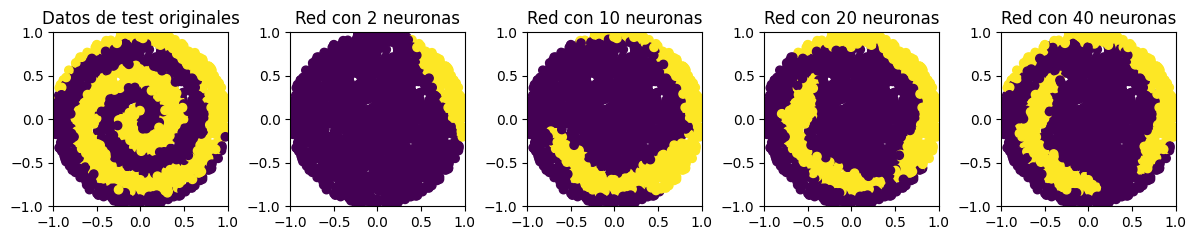

In [37]:
y1_out = cl1.predict(X_test)
y2_out = cl2.predict(X_test)
y3_out = cl3.predict(X_test)
y4_out = cl4.predict(X_test)


fig, axes = plt.subplots(1, 5, figsize=(12, 5))

axes[0].set_title('Datos de test originales')
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis')

axes[1].set_title('Red con 2 neuronas')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y1_out, cmap='viridis')

axes[2].set_title('Red con 10 neuronas')
axes[2].scatter(X_test[:, 0], X_test[:, 1], c=y2_out, cmap='viridis')

axes[3].set_title('Red con 20 neuronas')
axes[3].scatter(X_test[:, 0], X_test[:, 1], c=y3_out, cmap='viridis')

axes[4].set_title('Red con 40 neuronas')
axes[4].scatter(X_test[:, 0], X_test[:, 1], c=y4_out, cmap='viridis')


for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

### Conclusiones

Comparando las predicciones para las redes con 2, 10, 20 y 40 neuronas en la capa oculta, se observa que aumentar la cantidad de neuronas incrementa la capacidad de representación del modelo, permitiéndole aproximar mejor la topología no lineal del problema de las espirales y, en este rango de neuronas en el cual todavía no se llega a hacer overfitting, clasificar correctamente una mayor cantidad de puntos (disminuyendo el error de prueba).Durante la propagación hacia adelante, cada neurona de la capa oculta procesa el vector de entrada de forma independiente, aplicando una transformación no lineal. Una vez que la red completa produce una salida, se evalúa el error global respecto al valor esperado ($y_test$). Dado que la actualización de pesos mediante Backpropagation se mueve en dirección opuesta al gradiente de la función de error total, cada neurona oculta ajusta iterativamente sus parámetros. De esta forma, las neuronas "cooperan" para que cada vez se ajuste más a la topología de las espirales.

Sin embargo, todavía la predicción de las espirales es mala aún así teniendo una capa oculta con 40 neuronas. Nuestras hipótesis de por qué puede esto ser así son las siguientes:


La cantidad de capas ocultas no es lo suficientemente grande como para modelar

1.   La cantidad de capas ocultas no es lo suficientemente grande como para modelar de forma sencilla las espirales. Si bien en el Mitchell se menciona que toda función continua puede ser modelada con una red de 2 capas, es decir una capa oculta y una capa de salida, el número de neuronas necesarias en la capa oculta para aproximar dicha función puede ser altísimo. Mismo caso para la representación de funciones arbitrarias que requiere 3 capas. Por lo tanto aumentando la cantidad de capas podemos agregar características no lineales a la clasificación, sin aumentar significativamente la cantidad de neuronas totales.
2.   La función de activación utilizada puede no ser adecuada para el problema. La forma de la espiral podría ser mejor aproximada con una función periódica sencillamente por su naturaleza. De hecho existe una arquitectura moderna llamada SIREN que utiliza Seno como la función de activación de cada neurona.

La función sigmoide es monótonamente creciente, por lo que claramente no es periódica. Sin embargo, la monotonía de la función no es el problema principal ya que, por ejemplo, ReLU es monótona creciente y se usa globalmente. Lo que ocurre es que hay un problema con la saturación de la sigmoide.

Recordemos que la sigmoide para valores muy grandes de $\vec{w}.\vec{x}$ es cercana a 1 y para valores muy chicos (y negativos) de $\vec{w}.\vec{x}$ es cercana a 0. Por lo tanto su derivada, la cual es $\sigma(\vec{w}.\vec{x})(1-\sigma(\vec{w}.\vec{x}))$ se anula del lado derecho cuando $\vec{w}.\vec{x}$ es muy grande, y se anula del lado izquierdo cuando $\vec{v}.\vec{v}$ es muy chico. Esto se lo conoce como **desvanecimiento de gradiente**, donde la derivada de la sigmoide es muy cercana a 0 y el algoritmo se estanca.

Un pequeño ejemplo de una red con varias capas y con algunos parámetros cambiados.

c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


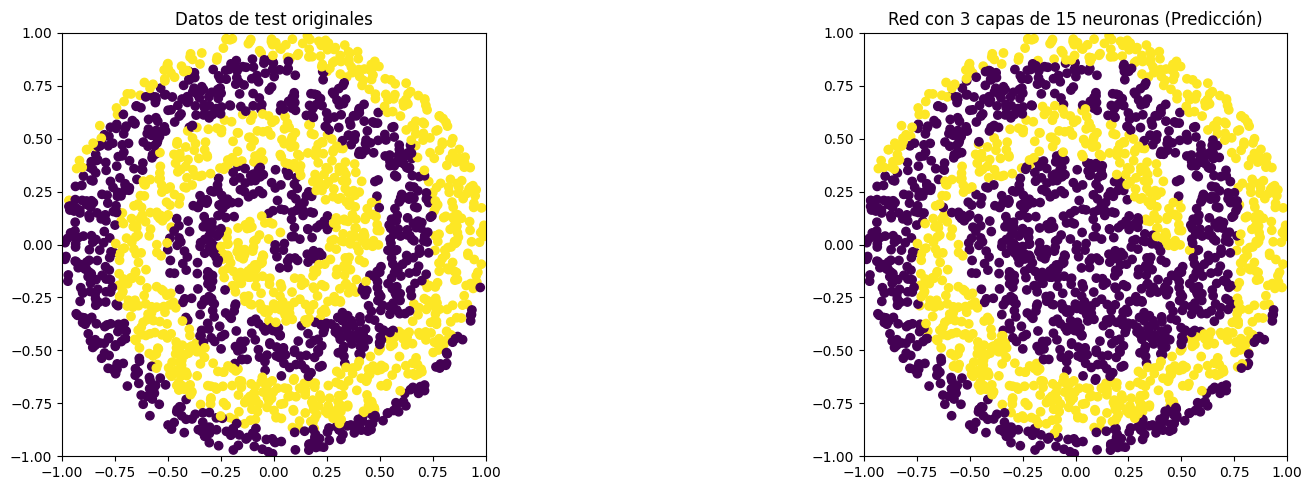

In [38]:
red5 = MLPClassifier(
    hidden_layer_sizes=(15, 15, 15), activation='relu', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.001,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=200
)
cl5, e5_train, e5_val, e5_test, e5_bestErr = entrenar_red(red5, 1000, X_train, y_train, X_val, y_val, X_test, y_test)

y5_out = cl5.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].set_title('Datos de test originales')
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis')

axes[1].set_title('Red con 3 capas de 15 neuronas (Predicción)')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y5_out, cmap='viridis')

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

# Ejercicio 2. Mínimos Locales.

Creando las redes...

In [39]:
#Primero cargamos el csv
X, y = cargar_csv('dos_elipses.data')

# spliteamos los datos de entrenamiento en entrenamiento y validación
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X, y, test_size=100)

X_test, y_test = cargar_csv('dos_elipses.test')

#Entrenando las redes
COMENTARIO: Lo que nos devuelve la función "entrenar_red" para el valor "e_test" es un vector de los errores que tenía la predicción para cada super-época cuando se entrenó la red. Entonces, a fin de este ejercicio, necesitamos elegir algún error candidato para que aporte al promedio de los 10 entrenamientos aleatorios con los mismos parámetros de la red.

Para esto modificamos la función entrenar_red, de manera que ahora devuelve el error de la mejor red, es decir, la que devuelve como primer argumento dicha función. Esta función es la que se espera que tenga el menor error posible.

Además, se usa la librería joblib para tratar de paralelizar los entrenamientos de redes. Desafortunadamente, la librería sklearn no permite paralelizar el cómputo de entrenamiento dentro de una misma red ni tampoco utilizar la GPU como entorno de ejecución.
Por lo tanto, lo que deberíamos ganar paralelizando es que los 10 entrenamientos para cada combinación de eta y alfa se hagan en paralelo. Digo "deberiamos" ya que si estamos con la versión gratuita de google colab, éste solo nos provee dos cores de CPU, por lo que a lo sumo podemos entrenar dos redes a la vez.

In [40]:
from joblib import Parallel, delayed

etas = [0.1, 0.01, 0.001]
alfas = [0.0, 0.5, 0.9]

def evaluar_configuracion(e, a, X_train, y_train, X_val, y_val, X_test, y_test):
    errores_repeticiones = []
    for j in range(10):
        red_exp = MLPClassifier(
            hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=1, learning_rate='constant', learning_rate_init=e,
            momentum=a, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=50
        )

        _, _, _, _, best_err_test = entrenar_red(
            red_exp, 300, X_train, y_train, X_val, y_val, X_test, y_test
        )
        errores_repeticiones.append(best_err_test)

    media_error = np.mean(errores_repeticiones)
    desviacion_error = np.std(errores_repeticiones)

    return {
        'eta': e,
        'alfa': a,
        'test_error_medio': media_error,
        'porcentaje_error_test': f"{media_error:.2%}",
        'test_error_std': desviacion_error,
        'historial_completo': errores_repeticiones
    }

# Ejecución paralela sobre las combinaciones de eta y alfa
resultados_experimentos = Parallel(n_jobs=-1)(
    delayed(evaluar_configuracion)(e, a, X_train, y_train, X_val, y_val, X_test, y_test)
    for e in etas for a in alfas
)

In [41]:
df_resultados = pd.DataFrame(resultados_experimentos)
display(df_resultados[['eta', 'alfa', 'test_error_medio','porcentaje_error_test', 'test_error_std']])
display(df_resultados.sort_values(by='test_error_medio').reset_index(drop=True))

,eta,alfa,test_error_medio,porcentaje_error_test,test_error_std
0,0.100,0.0,0.0656,6.56%,0.075031
1,0.100,0.5,0.0384,3.84%,0.044586
2,0.100,0.9,0.0884,8.84%,0.064413
3,0.010,0.0,0.2435,24.35%,0.000000
4,0.010,0.5,0.1759,17.59%,0.079545
5,0.010,0.9,0.0481,4.81%,0.075682
6,0.001,0.0,0.2435,24.35%,0.000000
7,0.001,0.5,0.2435,24.35%,0.000000
8,0.001,0.9,0.2435,24.35%,0.000000


,eta,alfa,test_error_medio,porcentaje_error_test,test_error_std,historial_completo
0,0.100,0.5,0.0384,3.84%,0.044586,"[0.015000000000000013, 0.013000000000000012, 0..."
1,0.010,0.9,0.0481,4.81%,0.075682,"[0.14100000000000001, 0.010499999999999954, 0...."
2,0.100,0.0,0.0656,6.56%,0.075031,"[0.010499999999999954, 0.013499999999999956, 0..."
3,0.100,0.9,0.0884,8.84%,0.064413,"[0.04700000000000004, 0.03749999999999998, 0.0..."
4,0.010,0.5,0.1759,17.59%,0.079545,"[0.24350000000000005, 0.15749999999999997, 0.2..."
5,0.010,0.0,0.2435,24.35%,0.000000,"[0.24350000000000005, 0.24350000000000005, 0.2..."
6,0.001,0.0,0.2435,24.35%,0.000000,"[0.24350000000000005, 0.24350000000000005, 0.2..."
7,0.001,0.5,0.2435,24.35%,0.000000,"[0.24350000000000005, 0.24350000000000005, 0.2..."
8,0.001,0.9,0.2435,24.35%,0.000000,"[0.24350000000000005, 0.24350000000000005, 0.2..."


Graficamos los errores de test, validación y entrenamiento de la red con los mejores parámetros alfa y eta. Estos son los que minimizan el promedio de los (mejores) errores de test en 10 entrenamientos distintos de una red con dichos parámetros.

In [ ]:
mejor_idx = df_resultados['test_error_medio'].idxmin()
mejor_eta = df_resultados.loc[mejor_idx, 'eta']
mejor_alfa = df_resultados.loc[mejor_idx, 'alfa']

red_mejor = MLPClassifier(
    hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=mejor_eta,
    momentum=mejor_alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=50
)

_, e_train, e_val, e_test, _ = entrenar_red(
    red_mejor, 300, X_train, y_train, X_val, y_val, X_test, y_test
)

rango_epocas = np.arange(300) * 50
plt.figure(figsize=(10, 6))
plt.plot(rango_epocas, e_train, label='Train Error', linestyle=':')
plt.plot(rango_epocas, e_val, label='Validation Error', linestyle='-.')
plt.plot(rango_epocas, e_test, label='Test Error', linestyle='-')

plt.title(f'Curvas de Error (eta={mejor_eta}, alfa={mejor_alfa})')
plt.xlabel('Épocas')
plt.ylabel('Error (Zero-One Loss)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Conclusiones.
(DISCLAIMER: Escribimos las conclusiones, pero después tuvimos que correr el test denuevo por si hay alguna incongruencia)

Habiendo realizado varias ejecuciones del test, la combinación de *eta* y *alfa* que mejor funciona no es siempre la misma. Esto es esperable, ya que es un proceso aleatorio, por lo que en algunos entrenamientos puede ocurrir que ciertos valores de dichos parámetros se ajusten mejor a los conjuntos generados aleatoriamente. Sin embargo, esto no quiere decir que cualquier combinación de parámetros sea buena, hay ciertos valores que nunca devuelven un buen error y por lo tanto podemos descartarlos en el uso de entrenamiento de redes para este problema de aprendizaje.

Para aquellos valores que tienen un **learning rate muy bajo** (en nuestro caso de test $\eta = 0.001$) siempre obtenemos errores altos, en general mayores al 20%. Además para valores con un momentum bajo o medio ($\alpha = 0.1$ o $\alpha = 0.5$) el desvio estándar es 0, lo cuál nos dice que en los 10 distintos entrenamientos de esa red siempre se tuvo el mismo error. Esto ocurre ya que un learning rate bajo implica no modificar los pesos  significativamente paso a paso, y sumado a que nuestro momentum no es lo suficientemente grande como para salir de esos mínimos locales nos quedamos atrapados en esos errores altos.

Para valores que tienen un **learning rate moderado** ($\eta = 0.01$) se ve que el gradiente cambia significativamente paso a paso, pero aún así tiene problemas si el momentum no es lo suficientemente grande ya que, a pesar de ser mayor a ese 0.001 que vimos anteriormente, $\eta$ no es lo suficientemente grande como para escapar de mínimos locales por sí solo y el gradiente nuevamente se vuelve cercano a 0, por lo que deja de descender. Para un momentum de $\alpha = 0.9$ logramos poder de escapar de algunos mínimos locales y el error cae significativamente. Esto ocurre ya que ahora sí tenemos un momentum suficientemente grande.

Para valores con un **learning rate alto** ($\eta = 0.1$) el algoritmo por sí solo ya hace cambios muy grandes en los pesos paso a paso, viendo la función de error como una superficie en el espacio de los pesos esto significa que nuestro algoritmo va a ir saltando por distintos puntos de la superficie con mayor distancia escapando muchas veces de mínimos locales de manera autónoma (autónoma en el sentido de que puede escapar de estos mínimos sin ayuda del momentum). Combinado con los distintos valores de $\alpha$ vemos que la combinación que mejor resultado da es con $\alpha = 0.5$ donde pensamos que es el punto medio en el cual aumenta la distancia de los pasos que hace pero sin ser exageradamente grande y que simplemente vaya escapando de todos los mínimos locales que ve.

Como conclusión general, es difícil encontrar los parámetros exactos y óptimos de $\eta$ y $\alpha$ para que minimicen el error, pero sí a través de múltiples ejecuciones se pueden descartar ciertos candidatos y elegir ciertos otros. Las distintas topologías o distribuciones de cada problema tendrán valores muy distintos, los cuales deben ser aproximados a través de varias ejecuciones midiendo el error en el conjunto de validación. 

# Ejercicio 3. Regularización

c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: Conver

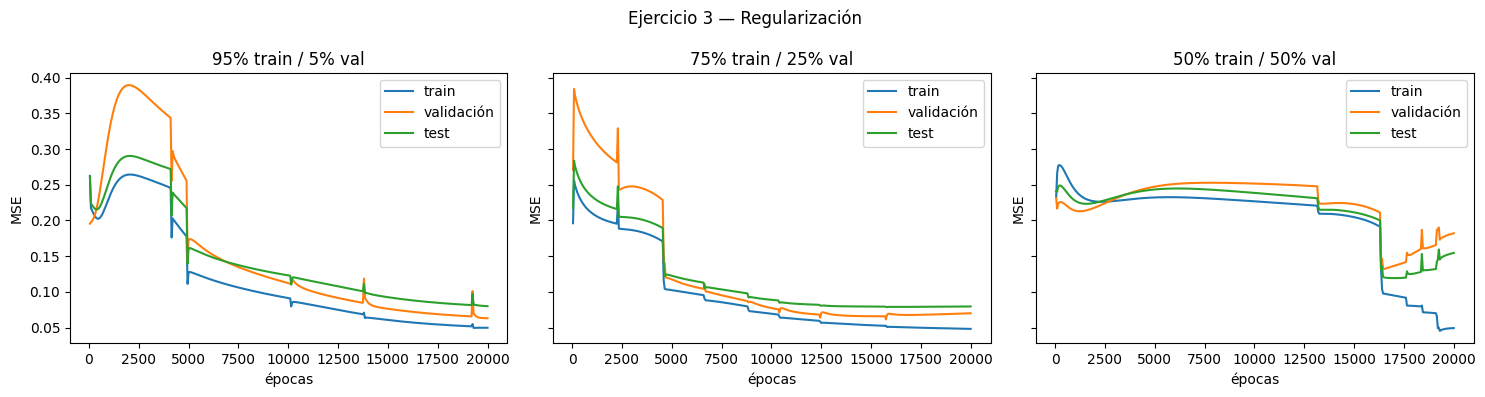

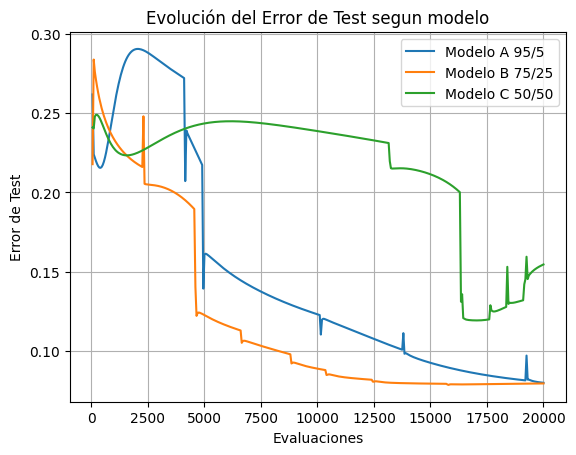

In [11]:
learning_rate_ikeda = 0.01
momentum_ikeda = 0.9
neuronas_capa_oculta_ikeda = 30

evaluaciones_ikeda = 400
epocas_ikeda = 50

X_ikeda, y_ikeda = cargar_csv("ikeda.data",xcols=5, sep=r"\s+")

X_test_ikeda, y_test_ikeda = cargar_csv("ikeda.test",xcols=5, sep=r"\s+")
X_test_ikeda = X_test_ikeda.iloc[:2000]
y_test_ikeda = y_test_ikeda.iloc[:2000]


proporciones = [
    ("95% train / 5% val", 0.05),
    ("75% train / 25% val", 0.25),
    ("50% train / 50% val", 0.50),
]
error_vals = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

epocas_axis = np.arange(1, evaluaciones_ikeda + 1) * epocas_ikeda

for ax, (titulo, val_size) in zip(axes, proporciones):
    X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
        X_ikeda,
        y_ikeda,
        test_size=val_size,
        random_state=3,
    )

    red = MLPRegressor(
        hidden_layer_sizes=(neuronas_capa_oculta_ikeda,),
        activation="logistic",
        solver="sgd",
        alpha=0.0,
        batch_size=1,
        learning_rate="constant",
        learning_rate_init=learning_rate_ikeda,
        momentum=momentum_ikeda,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=epocas_ikeda,
        random_state=3
    )


    best_red, e_train, e_val, e_test = entrenar_red_reg(
        red,
        evaluaciones_ikeda,
        X_train, y_train,
        X_val, y_val,
        X_test_ikeda, y_test_ikeda,
    )

    error_vals.append(e_test)

    ax.plot(epocas_axis, e_train, label="train")
    ax.plot(epocas_axis, e_val, label="validación")
    ax.plot(epocas_axis, e_test, label="test")

    ax.set_title(titulo)
    ax.set_xlabel("épocas")
    ax.set_ylabel("MSE")

    ax.legend()


plt.suptitle("Ejercicio 3 — Regularización")

plt.tight_layout()
plt.show()

# Graficamos error de test para cada red
plt.plot(epocas_axis, error_vals[0], label='Modelo A 95/5')
plt.plot(epocas_axis, error_vals[1], label='Modelo B 75/25')
plt.plot(epocas_axis, error_vals[2], label='Modelo C 50/50')

plt.xlabel('Evaluaciones')
plt.ylabel('Error de Test')
plt.title('Evolución del Error de Test segun modelo')
plt.legend()
plt.grid(True)
plt.show()

### Conclusiones del Ejercicio 3
Al evaluar las distintas particiones del dataset de Ikeda, se determina que la proporción 75% entrenamiento / 25% validación es la óptima. La razón detrás de esto es que esta distribución de datos de entrenamiento y de validación es un punto medio entre los problemas que tienen los modelos 95-5 y 50-50.

**Modelo A**(Sesgo de validación): Aunque la convergencia en entrenamiento es rápida debido al gran volumen de datos, el conjunto de validación no es lo suficientemente grande como para ser estadisticamente significativo. Esto provoca que la curva de validación sea volátil y engañosa, por ejemplo podríamos notar un decrecimiento en el error de validación simplemente porque nuestra red predijo bien ese conjunto pequeño de datos que no representaban la verdadera naturaleza del problema, y entonces tendríamos un bajo error artificial o no real. El conjunto de validación actúa como un estimador excesivamente ruidoso.

**Modelo C** (Convergencia lenta): Al reducir drásticamente los datos de entrenamiento, la red realiza menos actualizaciones de pesos por época, retrasando severamente la convergencia. Además, al carecer de la cantidad de datos necesarios para capturar un patrón continuo complejo, el modelo se mantiene mucho tiempo subajustando. Esto explica por qué las curvas de error de entrenamiento y validación se mantienen casi idénticas y elevadas durante gran parte del proceso.

**Modelo B** (Balance): Representa un punto medio ideal para este problema. Proporciona suficientes ejemplos para que la red capture la naturaleza del problema rápidamente (estabilizando el error cerca de la época 2500) y reserva un conjunto de validación de tamaño adecuado para evaluar el rendimiento de forma significativa, logrando el menor error de test de los tres escenarios analizados.

# Ejercicio 4. Regularización (2).

In [18]:
def norma_pesos(red):
    """Calcula la suma de los cuadrados de todos los pesos de la red (‖w‖²)."""
    return sum(np.sum(np.square(a)) for a in red.coefs_)


def entrenar_red_penalizacion(red, evaluaciones,
                              X_train, y_train,
                              X_test, y_test):
    error_train = []
    error_pen = []
    error_test = []

    for epoch in range(evaluaciones):
        red.fit(X_train, y_train)

        y_pred_train = red.predict(X_train)
        error_train.append(mean_squared_error(y_train, y_pred_train))

        cur_pen = norma_pesos(red)
        error_pen.append(cur_pen)

        y_pred_test = red.predict(X_test)
        error_test.append(mean_squared_error(y_test, y_pred_test))

    return red, error_train, error_pen, error_test

learning_rate_ssp = 0.05
momentum_ssp = 0.3
neuronas_capa_oculta_ssp = 6
evaluaciones_ssp = 4000
epocas_ssp = 20

X_ssp, y_ssp = cargar_csv("ssp.data", xcols=12)
X_test_ssp, y_test_ssp = cargar_csv("ssp.test", xcols=12)

gammas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
tabla_gamma = []

resultados_por_gamma = {}

def entrenar_por_gamma(gamma, X_train, y_train, X_test, y_test):
    red = MLPRegressor(
        hidden_layer_sizes=(neuronas_capa_oculta_ssp,),
        activation="logistic",
        solver="sgd",
        alpha=gamma,
        batch_size=1,
        learning_rate="constant",
        learning_rate_init=learning_rate_ssp,
        momentum=momentum_ssp,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=epocas_ssp,
        random_state=2
    )

    # Entrenamos
    trained_red, e_train, e_pen, e_test = entrenar_red_penalizacion(
        red, evaluaciones_ssp, X_train, y_train, X_test, y_test
    )

    fila_tabla = {
        "gamma": gamma,
        "mse_train_final": e_train[-1],
        "mse_test_min": min(e_test),
        "mse_test_final": e_test[-1],
        "pen_final": e_pen[-1],
    }

    return gamma, (trained_red, e_train, e_pen, e_test), fila_tabla


resultados_paralelos = Parallel(n_jobs=-1)(
    delayed(entrenar_por_gamma)(gamma, X_ssp, y_ssp, X_test_ssp, y_test_ssp) for gamma in gammas
)


tabla_gamma = []
resultados_por_gamma = {}

for gamma, tupla_resultados, fila_tabla in resultados_paralelos:
    resultados_por_gamma[gamma] = tupla_resultados
    tabla_gamma.append(fila_tabla)

tabla_gamma = sorted(tabla_gamma, key=lambda x: x['gamma'])



--- TABLA DE RESULTADOS ---
   gamma  mse_train_final  mse_test_min  mse_test_final  pen_final
0.000001         0.003373      0.004456        0.004785  57.835454
0.000010         0.003477      0.004496        0.004619  46.794519
0.000100         0.005038      0.005166        0.005166  15.755454
0.001000         0.008043      0.007330        0.007375   5.392849
0.010000         0.024409      0.022598        0.022661   1.372365
0.100000         0.042611      0.038262        0.039098   0.000017
1.000000         0.042634      0.038724        0.039157   0.000113


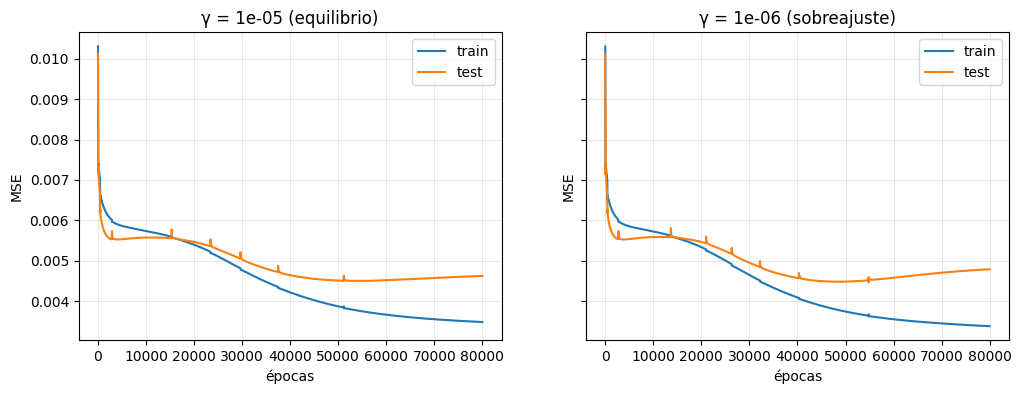

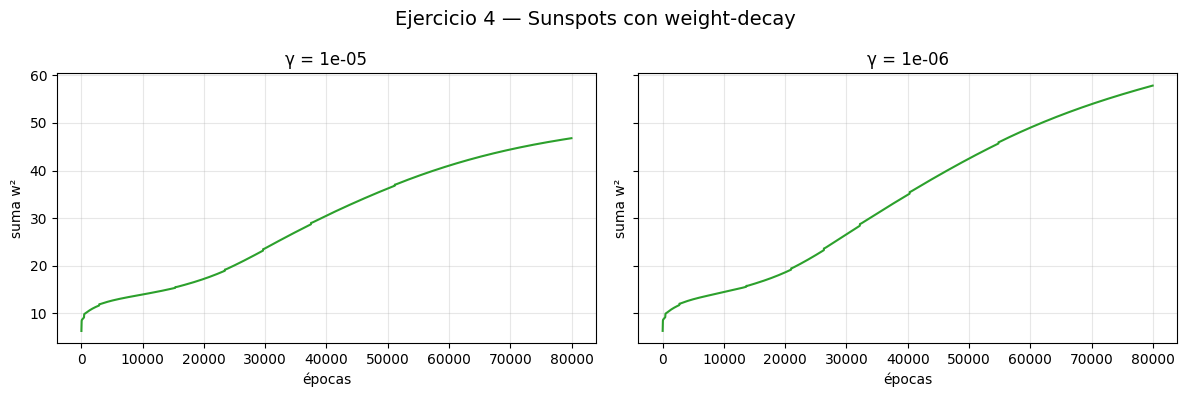

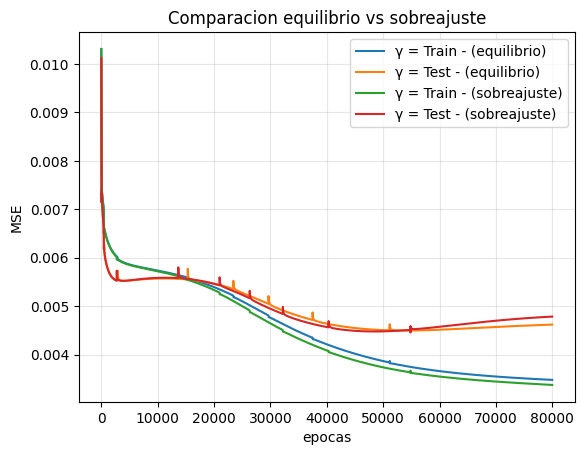

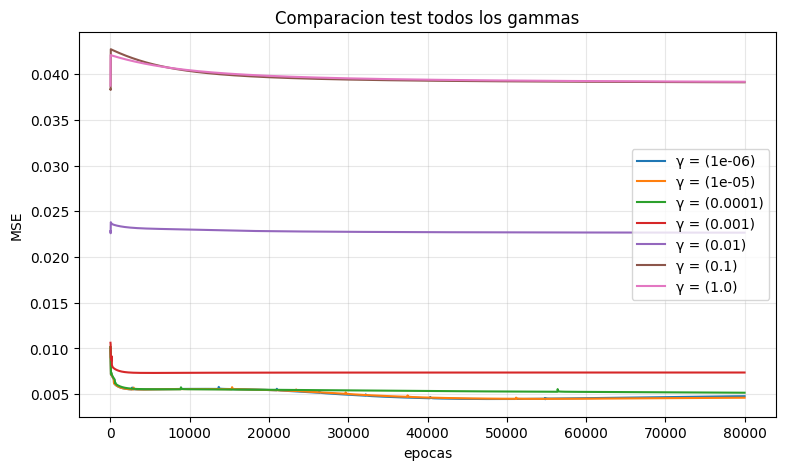

In [19]:
df_gamma = pd.DataFrame(tabla_gamma)
print("\n--- TABLA DE RESULTADOS ---")
print(df_gamma.to_string(index=False))


gamma_equilibrio = 1e-5
gamma_sobreajuste = 1e-6

epocas_ssp_axis = rango = np.array(range(evaluaciones_ssp)) * epocas_ssp

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

casos_grafico = [
    ("equilibrio", gamma_equilibrio),
    ("sobreajuste", gamma_sobreajuste),
]

for col, (etiqueta, gamma) in enumerate(casos_grafico):
    _, e_train, e_pen, e_test = resultados_por_gamma[gamma]

    axes[col].plot(epocas_ssp_axis, e_train, label="train")
    axes[col].plot(epocas_ssp_axis, e_test, label="test")
    axes[col].set_title(f"γ = {gamma:g} ({etiqueta})")
    axes[col].set_xlabel("épocas")
    axes[col].set_ylabel("MSE")
    axes[col].legend()
    axes[col].grid(True, alpha=0.3)



fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for col, (etiqueta, gamma) in enumerate(casos_grafico):
    _, e_train, e_pen, e_test = resultados_por_gamma[gamma]

    axes[col].plot(epocas_ssp_axis, e_pen, color="tab:green")
    axes[col].set_title(f"γ = {gamma:g}")
    axes[col].set_xlabel("épocas")
    axes[col].set_ylabel("suma w²")
    axes[col].grid(True, alpha=0.3)

plt.suptitle("Ejercicio 4 — Sunspots con weight-decay", fontsize=14)
plt.tight_layout()
plt.show()

for (etiqueta, gamma) in casos_grafico:
    _, e_train, e_pen, e_test = resultados_por_gamma[gamma]
    plt.plot(epocas_ssp_axis, e_train, label=f"γ = Train - ({etiqueta})")
    plt.plot(epocas_ssp_axis, e_test, label=f"γ = Test - ({etiqueta})")

plt.xlabel('epocas')
plt.ylabel('MSE')
plt.title('Comparacion equilibrio vs sobreajuste')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))

for gamma, (_, e_train, e_pen, e_test) in resultados_por_gamma.items():
    plt.plot(epocas_ssp_axis, e_test, label=f"γ = ({gamma})")


plt.xlabel('epocas')
plt.ylabel('MSE')
plt.title('Comparacion test todos los gammas')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()




### Conclusiones
Al evaluar distintos órdenes de magnitud para el $\gamma$ usado en Weight-Decay, observamos un claro compromiso entre la capacidad de ajuste y la generalización del modelo.

Región de sobreajuste ($\gamma = 10^{-6}$ o menores): Para valores de $\gamma$ muy pequeños, el término de penalización es numéricamente despreciable o muy chico. La red opera aproximadamente como si no se hiciera Weight-Decay, permitiendo que la magnitud de los pesos (la norma $\Vert w \Vert^2$) crezca indefinidamente con tal de forzar el error de entrenamiento hacia cero. En este caso la red tiene los clásicos problemas de sobreajuste que ya conocemos y que se mencionan en el Mitchell (en el libro se menciona que mientras más cercanos a 0 o más parecidos sean los pesos, la superficie que los aproxima es menos compleja y por lo tanto no ajusta tanto ruido). En la gráfica, como es de esperar, podemos ver como la brecha entre el error de train y el error de test crece. 

Región de subajuste ($\gamma$ elevados): Para valores de $\gamma$ muy grandes, el término correspondiente al Weight-Decay (el cual es $\gamma \sum_{i,j} w_{ji}^2$) domina la función de error. El algoritmo prioriza disminuir la magnitud de los pesos (manteniéndolos cerca de cero) por encima de aprender la naturaleza del problema (el primer término en la suma del error). Por lo que las actualizaciones de peso no se hacen a fin de mejorar los errores en la red, ya que se ven opacados por este segundo término de la sumatoria y nos produce errores altisimos tanto en test como en train.

Punto de Equilibrio ($\gamma = 10^{-5}$): Naturalmente, decidimos que este valor ofrece el mejor balance para este problema. De esta manera el $\gamma$ no es suficientemente grande como para tener el problema de subajuste que mencionamos arriba; ni suficientemente chico como para que el Weight-Decay prácticamente no haga efecto o sea despreciable.

# Ejercicio 5. Dimensionalidad.

In [42]:
from joblib import Parallel, delayed
import numpy as np

def experiment(generator, dimensions, C=0.78, n_train=250, n_test=10000):
  train_mean, train_std = [], []
  test_mean, test_std = [], []

  for d in dimensions:
    X_test, y_test = generator(d, C, n_test)

    def run_iteration():
      X, y = generator(d, C, n_train)

      X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
        X, y, test_size=0.2)  # PROVISIONAL HAY QUE VER CUALES VALORES SON ADECUADOS

      clasf_expr = MLPClassifier( # PROVISIONAL HAY QUE VER QUE VALORES SON ADECUADOS
        hidden_layer_sizes=(6,),
        activation='logistic',
        solver='sgd',
        alpha=0.0,
        batch_size=1,
        learning_rate='constant',
        learning_rate_init=eta,
        momentum=0.3,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=sub_epocas
      )

      # Obtenemos mejor red entrenada
      best_red, e_train, e_val, e_test, _ = entrenar_red(
        clasf_expr, super_epocas, X_train, y_train, X_val, y_val, X_test, y_test)

      # Train error de esta iteracion
      y_pred_train = best_red.predict(X_train)
      train_error = zero_one_loss(y_train, y_pred_train)

      # Test error de esta operacion
      test_error = 1 - best_red.score(X_test, y_test)
      
      return train_error, test_error

    # n_jobs=-1 significa "usar todos los núcleos disponibles"
    results = Parallel(n_jobs=-1)(delayed(run_iteration)() for _ in range(20))
    
    # Desempaquetamos los resultados
    train_errors = [res[0] for res in results]
    test_errors = [res[1] for res in results]

    train_mean.append(np.mean(train_errors))
    train_std.append(np.std(train_errors))
    test_mean.append(np.mean(test_errors))
    test_std.append(np.std(test_errors))

  return (np.array(train_mean), np.array(train_std), np.array(test_mean), np.array(test_std))

dimensions = np.array([2,4,8,16,32])
C = 0.78
n_train = 250
n_test = 10000

par_train_m, par_train_s, par_test_m, par_test_s = experiment(paralelas, dimensions, C, n_train, n_test)

diag_train_m, diag_train_s, diag_test_m, diag_test_s = experiment(diagonales, dimensions, C, n_train, n_test)


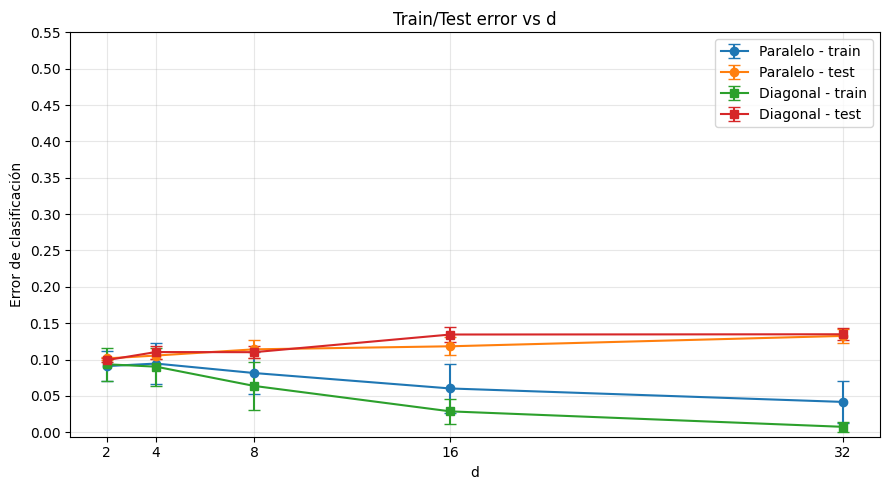

In [43]:
plt.figure(figsize=(9, 5))

plt.errorbar(dimensions, par_train_m, yerr=par_train_s, marker='o',
             capsize=4, label='Paralelo - train')
plt.errorbar(dimensions, par_test_m, yerr=par_test_s, marker='o',
             capsize=4, label='Paralelo - test')

plt.errorbar(dimensions, diag_train_m, yerr=diag_train_s, marker='s',
             capsize=4, label='Diagonal - train')
plt.errorbar(dimensions, diag_test_m, yerr=diag_test_s, marker='s',
             capsize=4, label='Diagonal - test')

plt.xlabel('d')
plt.ylabel('Error de clasificación')
plt.title('Train/Test error vs d')
plt.xticks(dimensions)
plt.grid(True, alpha=0.3)
plt.legend()
plt.yticks(np.arange(0, 0.6, 0.05))
plt.tight_layout()
plt.show()

### Conclusiones
Podemos ver que la evolucion de los errores conforme aumentan las dimensiones es muy similar. El poder de representación de las redes neuronales nos permite tratar al problema de paralelas y diagonales de la misma forma. Para la red, trazar una recta paralela o una diagonal es exactamente lo mismo ya que la manera de aproximar mejor la combinación lineal $w_0 + w_1x_1 + \dots + w_nx_n$ es rotando el hiperplano de los pesos. Por otro lado, cuando nuestro modelo de aprendizaje eran árboles de decisión cada nodo realizaba cortes ortogonales, el problema de paralelas se podia clasificar facilmente y el de diagonales se complejizaba al tener que representar una diagonal en muchas dimensiones con intervalos (formando una escalera con los cortes que realizaba). Esta facilidad que tienen las redes neuronales de aproximar ambos problemas se puede ver en la gráfica, donde la evolución del error de ámbos problemas es similar.

El error de test aumenta conforme hay mas dimensiones, lo cual es esperable al ser mas complejos los datos y entrenar utilizando la misma cantidad de neuronas, epocas y ejemplos de train. No es lógico pensar que un conjunto de 250 datos de entrenamiento aproxime igualmente un espacio de 2 dimensiones y uno de 32 dimensiones, claramente para hacer una mejor aproximación de un espacio con más dimensiones debemos aumentar la cantidad de datos de entrenamiento. El error de train va disminuyendo ya que es mas facil sobreajustar con datos mas complejos (de mayor dimensionalidad).

# (OPCIONAL) Ejercicio 6. Multiclase.

In [44]:
sub_epocas_6 = 10
super_epocas_6 = 100
iris = skl.datasets.load_iris()

X = iris.data
y = iris.target


# Hacemos el split de training y testing
X2, X_test, y2, y_test = skl.model_selection.train_test_split(
      X, y, test_size=1/3)  # para iris dataset de 150 me quedan 50 de test

# y spliteamos el training en training y validacion
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X2, y2, test_size=0.5)  # para iris dataset de 20 me quedan 20 de val

def iris_dataset_work():

  X = iris.data
  y = iris.target

  clasf_iris = MLPClassifier( # PROVISIONAL HAY QUE VER UQE VALORES SON ADECUADOS
        hidden_layer_sizes=(6,),
        activation='logistic',
        solver='sgd',
        alpha=0.0,
        batch_size=1,
        learning_rate='constant',
        learning_rate_init=eta,
        momentum=0.2,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=sub_epocas_6
  )

  # Corremos el entrenamiento
  return entrenar_red(
      clasf_iris, super_epocas_6, X_train, y_train, X_val, y_val, X_test, y_test)


iris_clasf, e_iris_train, e_iris_val, e_iris_test, _= iris_dataset_work()

c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: Conver

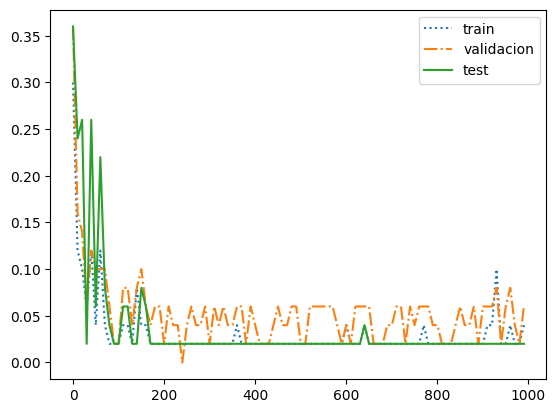

In [45]:
rango = np.array(range(super_epocas_6)) * sub_epocas_6
plt.plot(rango, e_iris_train, label="train", linestyle=":")
plt.plot(rango, e_iris_val, label="validacion", linestyle="-.")
plt.plot(rango, e_iris_test, label="test", linestyle="-")
plt.legend()
plt.show()

### Conclusiones Iris
Al observar las curvas de aprendizaje, se nota una convergencia rápida hacia un error cercano a cero en las primeras etapas del entrenamiento. Pensamos que esto no se debe únicamente a la baja dimensionalidad del conjunto de datos, sino a que como mencionamos en clase el problema de Iris es "de juguete" es sencillo y linealmente separables. Debido a esto la red neuronal captura la lógica del problema en muy pocas épocas, haciendo innecesario un entrenamiento prolongado que solo derivaría en un gasto computacional o en un eventual sobreajuste.

In [46]:
def faces_dataset_work():
  # Cargamos los datos...
  X_test_unscaled, y_test = cargar_csv("faces.test", xcols=960)

  X_unscaled, y = cargar_csv("faces.data", xcols=960)

  X_test= X_test_unscaled / 255.0
  X = X_unscaled / 255.0

  # y spliteamos el training en training y validacion
  X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
      X, y, test_size=0.2)

  clasf_faces = MLPClassifier(
        hidden_layer_sizes=(6,),  # PROVISIONAL HAY QUE VER UQE VALORES SON ADECUADOS
        activation='logistic',
        solver='sgd',
        alpha=0.0,
        batch_size=1,
        learning_rate='constant',
        learning_rate_init=eta,
        momentum=0.3,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=sub_epocas
  )

  # Corremos el entrenamiento
  return entrenar_red(
      clasf_faces, super_epocas, X_train, y_train, X_val, y_val, X_test, y_test)


faces_clasf, e_faces_train, e_faces_val, e_faces_test, _ = faces_dataset_work()

c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: Conver

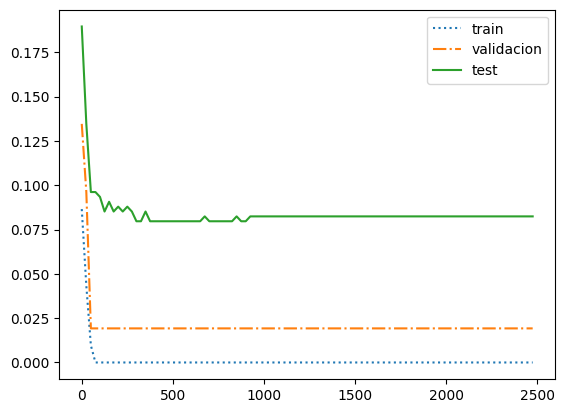

In [47]:
rango = np.array(range(super_epocas)) * sub_epocas
plt.plot(rango, e_faces_train, label="train", linestyle=":")
plt.plot(rango, e_faces_val, label="validacion", linestyle="-.")
plt.plot(rango, e_faces_test, label="test", linestyle="-")
plt.legend()
plt.show()

### Conclusiones Faces
Los resultados que nos quedaron en comparación con los del Mitchell son muy similares, aunque ligeramente peores, llegando a una accuracy del 90% aproximadamente bastante rápido, utilizando 6 neuronas ocultas (al querer representar unicamente un output con 4 posibilidades la utilización de pocas neuronas en la capa intermedia nos parece correcta). Intuitivamente, el tener pocas neuronas en la capa oculta fuerza al modelo a extraer de la cantidad gigantesca de neuronas de la capa de input sus características principales. Utilizar más neuronas mejora marginalmente la accuracy pero los tiempos de entrenamiento aumentan mucho y incluso si aumentamos demasiado la cantidad de neuronas podríamos llegar a sobreajustar la red.

También utilizamos un learning rate menor al del Mitchell, pero la convergencia se logro de igual forma.


# (OPCIONAL) Ejercicio 7. Minibatch.

In [48]:
# Cargamos los datos...
X7, y7 = cargar_csv('ssp.data', xcols=12)

X7_test, y7_test = cargar_csv('ssp.test', xcols=12)

error_vals = []

for bs in [1, 5, 20]:
  time.sleep(1)
  # spliteamos el training en training y validacion
  X7_train, X7_val, y7_train, y7_val = skl.model_selection.train_test_split(
      X7, y7, test_size=0.2)


  # Defino MLP para regresión
  regr_mini = MLPRegressor(
      hidden_layer_sizes=(6,),    # 6 neuronas en capa intermedia
      activation='logistic',
      solver='sgd',
      alpha=0.0,
      batch_size=bs,              # batch size variable
      learning_rate='constant',
      learning_rate_init=0.05,    # learning rate 0.05
      momentum=0.3,               # 0.3 momentum
      nesterovs_momentum=False,
      tol=0.0,
      warm_start=True,
      max_iter=200                # 200 epocas
  )

  best_red, e_train, e_val, e_test = entrenar_red_reg(
    regr_mini, 2000, X7_train, y7_train, X7_val, y7_val, X7_test, y7_test)

  error_vals.append(e_train)
  error_vals.append(e_val)
  error_vals.append(e_test)

c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


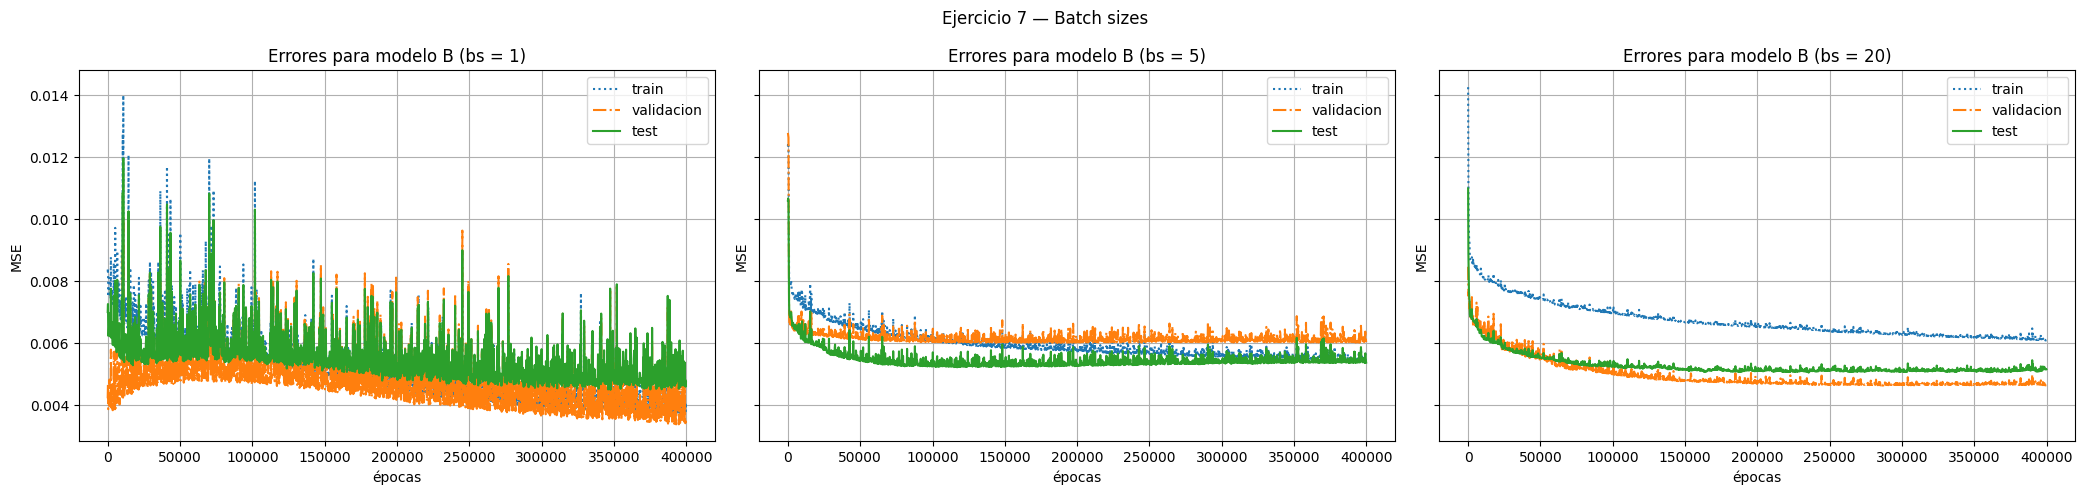

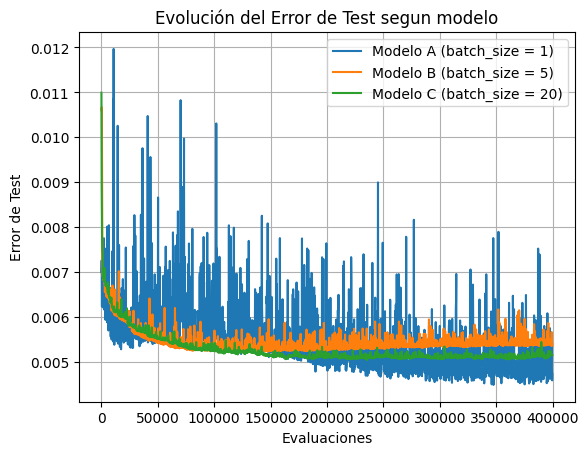

In [49]:

rango7 = np.array(range(2000)) * 200

fig, ax = plt.subplots(1, 3, figsize=(21, 5), sharey=True)

ax[0].plot(rango7, error_vals[0], label="train", linestyle=":")
ax[0].plot(rango7, error_vals[1], label="validacion", linestyle="-.")
ax[0].plot(rango7, error_vals[2], label="test", linestyle="-")
ax[0].set_title("Errores para modelo B (bs = 1)")
ax[0].set_xlabel("épocas")
ax[0].set_ylabel("MSE")
ax[0].grid(True)
ax[0].legend()


ax[1].plot(rango7, error_vals[3], label="train", linestyle=":")
ax[1].plot(rango7, error_vals[4], label="validacion", linestyle="-.")
ax[1].plot(rango7, error_vals[5], label="test", linestyle="-")
ax[1].set_title("Errores para modelo B (bs = 5)")
ax[1].set_xlabel("épocas")
ax[1].set_ylabel("MSE")
ax[1].grid(True)
ax[1].legend()

ax[2].plot(rango7, error_vals[6], label="train", linestyle=":")
ax[2].plot(rango7, error_vals[7], label="validacion", linestyle="-.")
ax[2].plot(rango7, error_vals[8], label="test", linestyle="-")
ax[2].set_title("Errores para modelo B (bs = 20)")
ax[2].set_xlabel("épocas")
ax[2].set_ylabel("MSE")
ax[2].grid(True)
ax[2].legend()


plt.suptitle("Ejercicio 7 — Batch sizes")

plt.tight_layout()

plt.show()

# Graficamos error de test para cada red
plt.plot(rango7, error_vals[2], label='Modelo A (batch_size = 1)')
plt.plot(rango7, error_vals[5], label='Modelo B (batch_size = 5)')
plt.plot(rango7, error_vals[8], label='Modelo C (batch_size = 20)')

plt.xlabel('Evaluaciones')
plt.ylabel('Error de Test')
plt.title('Evolución del Error de Test segun modelo')
plt.legend()
plt.grid(True)
plt.show()

### Conclusiones
Podemos ver que a menor batch size, el grafico se ve mas erratico, hace cambios bruscos en el error ya que las actualizaciones de peso se hacen por cada dato de entrenamiento y de ésta manera se actualizan pesos que a veces son simplemente ruido. Esto a veces da pasos que aumentan el error pero a través del tiempo se acercan al error objetivo.

Con mayores valores de batch size el grafico se ve mas consiso, siendo los errores menos erraticos ya que el gradiente se calcula como un promedio de todo el batch y se cancelan los ruidos individuales. Esto produce que tarde un poco más en descender el error, ya que las actualizaciones se hacen luego de una mayor cantidad de datos de entrenamiento procesados, por lo que generalmente el de batch size más chico llegara a un menor error mucho más rápido.

Aparte, tenemos que el modelo con menor batch size llegó a soluciones con menor error que el modelo con batch size=20 o batch size = 5. Creemos que esto se debe a que gracias a que el movimiento es más aleatorio, los modelos con menor batch size (en general) logran esquivar mínimos locales. Esto se debe a que cuando se usa batch size grande, el promedio no nos deja "saltar" de ese mínimo local y movernos por otro lado. 